# Exploratory Data Analysis (EDA) — Swindon LSOA GVA Project

**Topic:** *From Enterprise Structure to Economic Output: How SME Composition, Economic Resilience, and Employment Shape Local GVA in Swindon*

This notebook explores the cleaned dataset produced in `data_preprocessing.ipynb`. The goal is to understand variable distributions, bivariate relationships, and potential outliers **before** running regression models.

**Kernel :** Select **DS final project (.venv)** or interpreter path: `${workspaceFolder}/.venv/bin/python`

---

## Input / Output

| File | Description |
|------|-------------|
| `swindon_model_ready.csv` | Cleaned modelling dataset (127 LSOAs × 14 columns) |
| `features.csv` | Raw data (reference only; not used here) |

---

## Variables in the cleaned dataset

| Role | Variable |
|------|----------|
| **Y** | `log_GVA` (also inspect raw `LSOA GVA Estimates (millions)`) |
| **X1** | `LU_pct_large_2025_msoa` |
| **X2** | `LU_pct_micro_2025_msoa` |
| **X3** | `share_enterprises_kibs_2025_msoa` |
| **M1** | `turnover_diversity_1-HHI_2025_msoa` |
| **M2** | `employment_rate_per_pop` |
| **C1** | `Urban_rura` / `Urban_rura_binary` |
| **C2** | `Pct_Working_Age` |

**ID columns** (`LSOA21CD`, `LSOA21NM`, `MSOA21CD`, `MSOA21NM`) are for labelling only — do not include them in correlation matrices.

---

## EDA checklist

1. Load `swindon_model_ready.csv`
2. Summary statistics (`describe()`)
3. Distribution of GVA and log(GVA) — histograms
4. Correlation matrix + heatmap (numeric model variables only)
5. Urban vs Rural comparisons
6. Outlier inspection (high GVA, employment_rate > 1)
7. *(Optional)* Scatter plots: log_GVA vs key predictors

---

## Notes for interpretation

- **GVA is right-skewed**; `log_GVA` is the main outcome for regression.
- **`employment_rate_per_pop > 1`** is valid — workplace employment can exceed resident population (commuter hubs).
- **X1 and X2 are negatively correlated** (size shares sum to 1); do not interpret both in the same OLS model.
- **MSOA-level predictors repeat** within MSOA; note this when discussing independence in the final report.
- **Urban/rural status:** Derived from the ONS Rural-Urban Classification (2021) at LSOA level, as provided in the project dataset (`Urban_rura`; see `features_source.png` and ONS Open Geography). For regression, encoded as `Urban_rura_binary` (1 = Urban, 0 = Rural).

## 1. Load data and imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns   # optional, for heatmap later

df = pd.read_csv("swindon_model_ready.csv")
print("Shape:", df.shape)
df.head()

Shape: (127, 14)


,LSOA21CD,LSOA21NM,MSOA21CD,MSOA21NM,LSOA GVA Estimates (millions),LU_pct_large_2025_msoa,LU_pct_micro_2025_msoa,share_enterprises_kibs_2025_msoa,turnover_diversity_1-HHI_2025_msoa,employment_rate_per_pop,Urban_rura,Pct_Working_Age,log_GVA,Urban_rura_binary
0,E01015471,Swindon 028A,E02006849,Swindon 028,15.064,0.000000,0.844828,0.458333,0.770833,0.035149,Urban,0.667399,2.712308,1
1,E01015473,Swindon 008A,E02003219,Swindon 008,495.260,0.011236,0.820225,0.405229,0.816569,4.708314,Rural,0.612770,6.205083,0
2,E01015475,Swindon 015A,E02003226,Swindon 015,99.694,0.011765,0.823529,0.290323,0.830385,0.701684,Urban,0.712911,4.602105,1
3,E01015477,Swindon 015C,E02003226,Swindon 015,19.806,0.011765,0.823529,0.290323,0.830385,0.138198,Urban,0.711996,2.985985,1
4,E01015478,Swindon 021A,E02003232,Swindon 021,194.209,0.000000,0.895522,0.406780,0.765755,0.276583,Urban,0.695759,5.268935,1


## 2. Summary statistics

Use `df.describe()` on numeric columns. Confirm sample size (127 LSOAs) and check min/max for key variables.

In [5]:
df.describe()
#df.isnull().sum()   # 应全是 0

,LSOA GVA Estimates (millions),LU_pct_large_2025_msoa,LU_pct_micro_2025_msoa,share_enterprises_kibs_2025_msoa,turnover_diversity_1-HHI_2025_msoa,employment_rate_per_pop,Pct_Working_Age,log_GVA,Urban_rura_binary
count,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000
mean,93.414677,0.004285,0.850491,0.323683,0.784954,0.455478,0.653142,3.262485,0.889764
std,320.657803,0.007811,0.078445,0.076200,0.039257,0.839045,0.055789,1.339154,0.314424
min,4.977000,0.000000,0.693878,0.190476,0.730124,0.008043,0.497788,1.604827,0.000000
25%,9.239500,0.000000,0.767123,0.261261,0.747138,0.057844,0.618612,2.223458,1.000000
50%,16.131000,0.000000,0.877358,0.304348,0.771358,0.133601,0.650630,2.780743,1.000000
75%,63.327500,0.011111,0.913043,0.370370,0.830385,0.365902,0.693571,4.144154,1.000000
max,3412.047000,0.027397,0.960000,0.458333,0.841564,4.708314,0.768074,8.135068,1.000000


## 3. Distribution of GVA and log(GVA)

Plot histograms for:
- Raw GVA (`LSOA GVA Estimates (millions)`)
- `log_GVA`

**Purpose:** Justify the log transformation in the methods section.

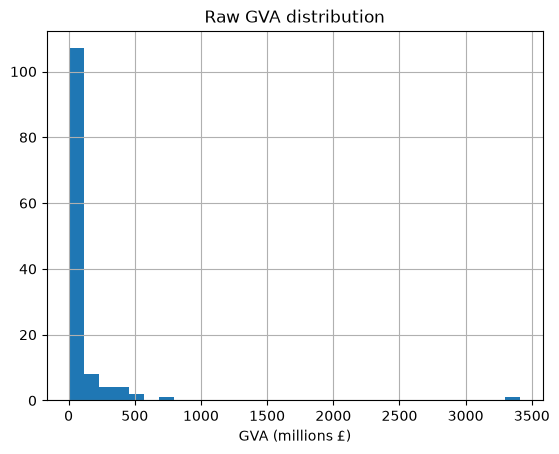

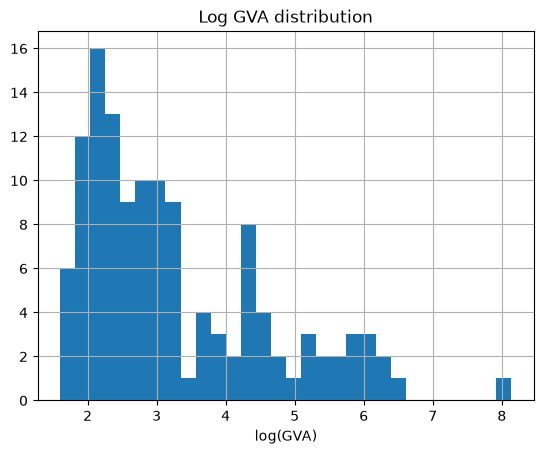

In [6]:
GVA_COL = "LSOA GVA Estimates (millions)"

df[GVA_COL].hist(bins=30)
plt.xlabel("GVA (millions £)")
plt.title("Raw GVA distribution")
plt.show()

df["log_GVA"].hist(bins=30)
plt.xlabel("log(GVA)")
plt.title("Log GVA distribution")
plt.show()

## 4. Correlation matrix and heatmap

Include numeric model variables only, e.g.:
`log_GVA`, X1–X3, M1, M2, `Pct_Working_Age`, `Urban_rura_binary`

**Look for:**
- Which predictors correlate most with `log_GVA`
- High correlation among predictors (multicollinearity)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
                                     log_GVA  LU_pct_large_2025_msoa  \
log_GVA                             1.000000                0.388696   
LU_pct_large_2025_msoa              0.388696                1.000000   
LU_pct_micro_2025_msoa             -0.482556               -0.694810   
share_enterprises_kibs_2025_msoa    0.097849                0.019267   
turnover_diversity_1-HHI_2025_msoa  0.540213                0.696857   
employment_rate_per_pop             0.737502                0.409393   
Pct_Working_Age                     0.069238               -0.058013   
Urban_rura_binary                  -0.089571                0.084934   

                                    LU_pct_micro_2025_msoa  \
log_GVA                                          -0.482556   
LU_pct_large_2025_msoa                           -0.694810   
LU_pct_micro_2025_msoa                            1.00

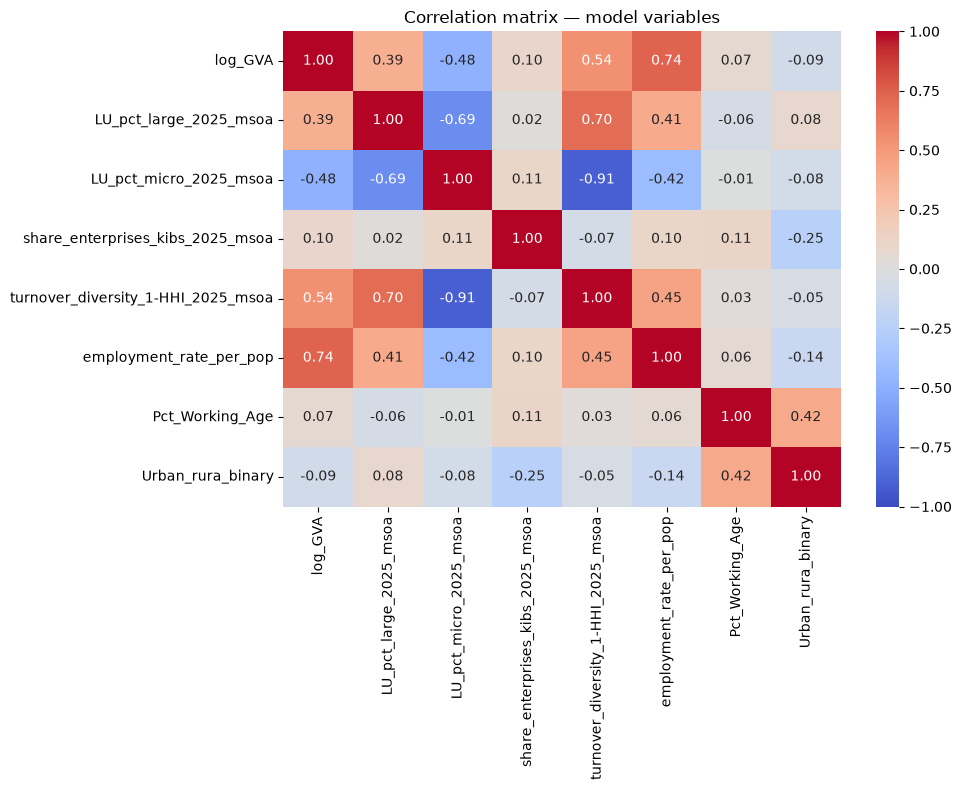

In [10]:
!pip install seaborn
import seaborn as sns

cols = [
    "log_GVA",
    "LU_pct_large_2025_msoa",
    "LU_pct_micro_2025_msoa",
    "share_enterprises_kibs_2025_msoa",
    "turnover_diversity_1-HHI_2025_msoa",
    "employment_rate_per_pop",
    "Pct_Working_Age",
    "Urban_rura_binary",
]

corr = df[cols].corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix — model variables")
plt.tight_layout()
plt.show()

## 5. Urban vs Rural comparison

Compare `log_GVA`, `employment_rate_per_pop`, or other variables by `Urban_rura`.

Options: grouped summary tables, boxplots, or bar charts.

### Definition of Urban / Rural

Urban/rural status is derived from the **ONS Rural-Urban Classification (2021)** at LSOA level, as provided in the project dataset (`Urban_rura`; see `features_source.png` and ONS Open Geography).

| Variable | Description |
|----------|-------------|
| `Urban_rura` | Text label: **Urban** or **Rural** (from ONS RUC 2021) |
| `RUC21NM` | Full ONS category (e.g. *Urban: Nearer to a major town or city*) |
| `Urban_rura_binary` | Regression coding: **1 = Urban**, **0 = Rural** |

In the Swindon sample: **113 Urban** and **14 Rural** LSOAs.

=== Summary table ===


log_GVA                 employment_rate_per_pop                
                mean    median count                    mean    median count
Urban_rura                                                                  
Rural       3.601919  3.169735    14                0.796615  0.220159    14
Urban       3.220431  2.740066   113                0.413214  0.122775   113


=== Boxplot ===


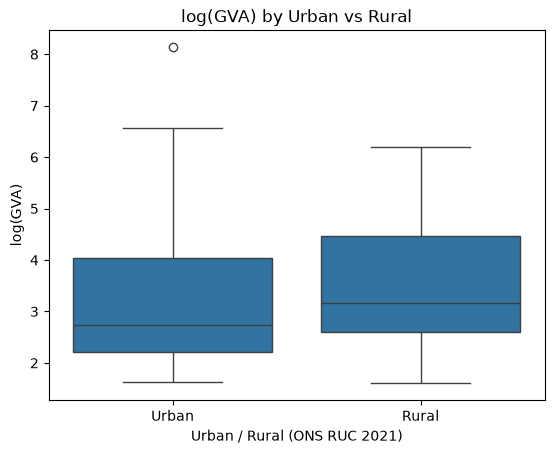


=== Bar chart ===


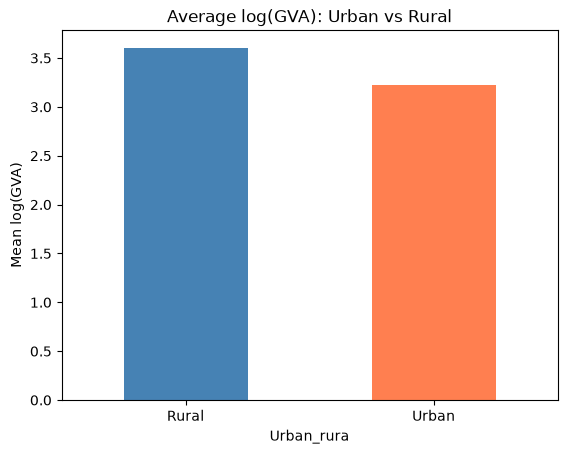

In [11]:
# --- A. Summary table ---
print("=== Summary table ===")
display(
    df.groupby("Urban_rura")[["log_GVA", "employment_rate_per_pop"]]
    .agg(["mean", "median", "count"])
)

# --- B. Boxplot ---
print("\n=== Boxplot ===")
sns.boxplot(data=df, x="Urban_rura", y="log_GVA")
plt.title("log(GVA) by Urban vs Rural")
plt.xlabel("Urban / Rural (ONS RUC 2021)")
plt.ylabel("log(GVA)")
plt.show()

# --- C. Bar chart (mean log_GVA) ---
print("\n=== Bar chart ===")
df.groupby("Urban_rura")["log_GVA"].mean().plot(kind="bar", color=["steelblue", "coral"])
plt.ylabel("Mean log(GVA)")
plt.title("Average log(GVA): Urban vs Rural")
plt.xticks(rotation=0)
plt.show()

## 6. Outlier and case inspection (six methods)

Apply six complementary approaches, then compare overlap at the end.

| # | Method | Purpose |
|---|--------|---------|
| 1 | **Top/bottom rows** (`nlargest` / `nsmallest`) | Name the most extreme LSOAs |
| 2 | **Rule-based flags** (`employment_rate > 1`, high GVA) | Clear, reportable rules |
| 3 | **Boxplot** | Visual points outside whiskers |
| 4 | **Z-score** (\|z\| > 2) | Statistical distance from mean |
| 5 | **Scatter plot** | Joint outliers (high employment & high GVA) |
| 6 | **Overlap comparison** | See which LSOAs appear in multiple methods |

**Columns to display:** `LSOA21NM`, `LSOA GVA Estimates (millions)`, `log_GVA`, `employment_rate_per_pop`, `Urban_rura`

**Report note:** Outliers often reflect **employment hubs** (commuters), not data errors. We describe them; we do not drop them in EDA.

In [ ]:
cols_show = [
    "LSOA21NM", "LSOA GVA Estimates (millions)", "log_GVA",
    "employment_rate_per_pop", "Urban_rura",
]
GVA_COL = "LSOA GVA Estimates (millions)"

# --- Method 1: Top / bottom log_GVA ---
print("=== Method 1: Top 10 log_GVA ===")
display(df.nlargest(10, "log_GVA")[cols_show])

print("\n=== Method 1: Bottom 5 log_GVA ===")
display(df.nsmallest(5, "log_GVA")[cols_show])

# --- Method 2: Rule-based flags ---
print("\n=== Method 2: employment_rate > 1 ===")
hubs = df[df["employment_rate_per_pop"] > 1].sort_values("employment_rate_per_pop", ascending=False)
print(f"Count: {len(hubs)}")
display(hubs[cols_show])

print("\n=== Method 2: GVA > 200 million ===")
high_gva = df[df[GVA_COL] > 200].sort_values(GVA_COL, ascending=False)
print(f"Count: {len(high_gva)}")
display(high_gva[cols_show])

# --- Method 3: Boxplots ---
print("\n=== Method 3: Boxplots ===")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df["log_GVA"], ax=axes[0])
axes[0].set_title("log(GVA)")
sns.boxplot(y=df["employment_rate_per_pop"], ax=axes[1])
axes[1].set_title("employment_rate_per_pop")
plt.tight_layout()
plt.show()

# --- Method 4: Z-score (|z| > 2) ---
print("\n=== Method 4: Z-score outliers (log_GVA) ===")
z = (df["log_GVA"] - df["log_GVA"].mean()) / df["log_GVA"].std()
z_outliers = df[z > 2].sort_values("log_GVA", ascending=False)
print(f"Count: {len(z_outliers)}")
display(z_outliers[cols_show])

# --- Method 5: Scatter plot ---
print("\n=== Method 5: Scatter log_GVA vs employment_rate ===")
plt.figure(figsize=(7, 5))
plt.scatter(df["employment_rate_per_pop"], df["log_GVA"], alpha=0.7)
plt.xlabel("employment_rate_per_pop")
plt.ylabel("log_GVA")
plt.title("Spot employment hubs and high-GVA LSOAs")
plt.show()

# --- Method 6: Overlap comparison ---
print("\n=== Method 6: Overlap across methods ===")
top10 = set(df.nlargest(10, "log_GVA")["LSOA21CD"])
hub_ids = set(hubs["LSOA21CD"])
z_ids = set(z_outliers["LSOA21CD"])
high_gva_ids = set(high_gva["LSOA21CD"])

print(f"Top 10 log_GVA:              {len(top10)} LSOAs")
print(f"employment_rate > 1:         {len(hub_ids)} LSOAs")
print(f"Z-score > 2 (log_GVA):       {len(z_ids)} LSOAs")
print(f"GVA > 200m:                  {len(high_gva_ids)} LSOAs")
print(f"In top10 AND hubs:           {top10 & hub_ids}")
print(f"In top10 AND z-score:        {top10 & z_ids}")
print(f"In all three (top10,hub,z):  {top10 & hub_ids & z_ids}")

,LSOA21NM,LSOA GVA Estimates (millions),log_GVA,employment_rate_per_pop,Urban_rura
49,Swindon 001F,4.977,1.604827,0.009033,Rural
16,Swindon 023D,5.126,1.634326,0.036058,Urban
40,Swindon 004C,5.253,1.658799,0.010438,Urban
65,Swindon 020E,5.362,1.679337,0.028302,Urban
62,Swindon 020B,6.161,1.818239,0.008892,Urban


## 7. (Optional) Scatter plots

Plot `log_GVA` against selected predictors (e.g. `employment_rate_per_pop`, `share_enterprises_kibs_2025_msoa`) to assess linearity and influential points.